In [1]:
%load_ext autoreload
%autoreload 2
%autosave 30
%matplotlib inline

Autosaving every 30 seconds


# Plot Spatial Errors for WB2

In [2]:
import re

import hvplot.polars  # noqa: F401
import numpy as np
import xarray as xr
from tqdm import tqdm

from genpp.data.weatherbench2 import (
    FC_VARS,
    FORECAST_ENS_PATH,
    OBSERVATIONS_FLAT_PATH,
    TEST_PREDICTIONS,
)
from genpp.eval import best_models

In [3]:
SCORE = "rmse"  # "rmse" or "crps"

In [4]:
predictions = []
_re = re.compile(r"predictions(?:_(?P<variant>.+))?$")

for model_name, models in best_models:
    for model in models:
        print(f"Processing model: {model_name}")
        for file in list(model.model_dir.rglob("test_predictions*.zarr")):
            print(file)
            model_dict = {}
            model_dict["name"] = model_name
            model_dict["tag"] = model.tag
            key = model_name
            if model.tag:
                key += f"_{model.tag}"
            m = _re.search(file.stem)
            suffix = m.group("variant") if m and m.group("variant") else None
            if suffix:
                key += f"_{suffix}"
            model_dict["dependency_model"] = suffix
            model_dict["full_name"] = key
            model_dict["file"] = file

            predictions.append(model_dict)

Processing model: emos
/home/feik/GenPP/outputs/EMOS/2026-02-15_17-09-13/test_predictions_gca.zarr
/home/feik/GenPP/outputs/EMOS/2026-02-15_17-09-13/test_predictions_ecc.zarr
Processing model: drn
/home/feik/GenPP/outputs/DRN/2026-02-06_13-30-02/test_predictions_gca.zarr
/home/feik/GenPP/outputs/DRN/2026-02-06_13-30-02/test_predictions_ecc.zarr
Processing model: chen
/home/feik/GenPP/outputs/CHEN/2026-02-06_14-37-36/test_predictions.zarr
Processing model: chen
/home/feik/GenPP/outputs/CHEN/2026-02-06_15-58-48/test_predictions.zarr
Processing model: chen
/home/feik/GenPP/outputs/CHEN/2026-02-06_17-48-35/test_predictions.zarr
Processing model: chen
/home/feik/GenPP/outputs/CHEN/2026-02-07_12-15-24/test_predictions.zarr
Processing model: chen
/home/feik/GenPP/outputs/CHEN/2026-02-06_18-44-54/test_predictions.zarr
Processing model: chen
/home/feik/GenPP/outputs/CHEN/2026-02-06_19-09-06/test_predictions.zarr
Processing model: chen
/home/feik/GenPP/outputs/CHEN/2026-02-06_20-38-55/test_predi

In [5]:
valid_times = TEST_PREDICTIONS.get_level_values("time") + TEST_PREDICTIONS.get_level_values(
    "prediction_timedelta"
)
gt = (
    xr.open_dataset(OBSERVATIONS_FLAT_PATH)[FC_VARS]
    .sel(time=valid_times)
    .rename({"time": "valid_time"})
    .assign_coords(prediction=("valid_time", TEST_PREDICTIONS))
    .swap_dims({"valid_time": "prediction"})
    .to_dataarray("feature")
    .transpose("prediction", "feature", "longitude", "latitude")
)

In [6]:
raw = (
    xr.open_dataset(FORECAST_ENS_PATH)[FC_VARS]
    .sel(
        time=TEST_PREDICTIONS.get_level_values("time").unique(),
        prediction_timedelta=TEST_PREDICTIONS.get_level_values("prediction_timedelta").unique(),
    )
    .stack(prediction=["time", "prediction_timedelta"])
    .sel(prediction=TEST_PREDICTIONS)
    .rename({"number": "sample"})
    .to_dataarray("feature")
    .transpose("prediction", "sample", "feature", "latitude", "longitude")
)

In [12]:
import torch

from genpp.models.scores import EnsembleCRPS


def compute_rmse(ds, gt):
    squared_errors = (ds - gt) ** 2
    rmse = np.sqrt(squared_errors.mean(dim=["prediction", "sample"]))
    return rmse


def compute_ensemble_crps(predictions: xr.DataArray, ground_truth: xr.DataArray) -> xr.DataArray:
    """
    Compute sample-based CRPS from a finite ensemble using xarray.
    """
    crps_metric = EnsembleCRPS()
    ds_tens = torch.tensor(predictions.to_numpy())
    gt_tens = torch.tensor(ground_truth.to_numpy())

    with torch.no_grad():
        crps = crps_metric(ds_tens, gt_tens)
    # Put back into xarray DataArray
    crps_xr = xr.DataArray(
        crps.cpu().numpy(),
        dims=gt.dims,
        coords=gt.coords,
    )

    return crps_xr.mean(dim="prediction")


if SCORE == "rmse":
    var_settings = {
        "2m_temperature": {
            "cmap": "magma",
            "label": "RMSE 2m temperature (K)",
            "vmax_cap": 3.5,
            "over_color": "cyan",
        },
        "10m_wind_speed": {
            "cmap": "viridis",
            "label": "RMSE 10m wind speed (m/s)",
            "vmax_cap": 2.24,
            "over_color": "hotpink",
        },
    }
    scoring_fn = compute_rmse
elif SCORE == "crps":
    var_settings = {
        "2m_temperature": {
            "cmap": "magma",
            "label": "CRPS 2m temperature",
            "vmax_cap": 1.8,
            "over_color": "cyan",
        },
        "10m_wind_speed": {
            "cmap": "viridis",
            "label": "CRPS 10m wind speed",
            "vmax_cap": 1.1,
            "over_color": "hotpink",
        },
    }
    scoring_fn = compute_ensemble_crps
else:
    raise ValueError(f"Invalid SCORE value: {SCORE}")

In [13]:
ensemble_score = scoring_fn(raw.transpose(..., "longitude", "latitude"), gt)

res = [ensemble_score]
pbar = tqdm(predictions)
for p in pbar:
    pbar.set_postfix_str(f"Processing model: {p['full_name']}")
    ds = xr.open_dataarray(p["file"], consolidated=True)
    e = scoring_fn(ds, gt)
    res.append(e)
combined = xr.concat(res, dim="model").assign_coords(
    model=["raw"] + [p["full_name"] for p in predictions]
)

100%|██████████| 24/24 [02:26<00:00,  6.10s/it, Processing model: engression_dir_mspes]


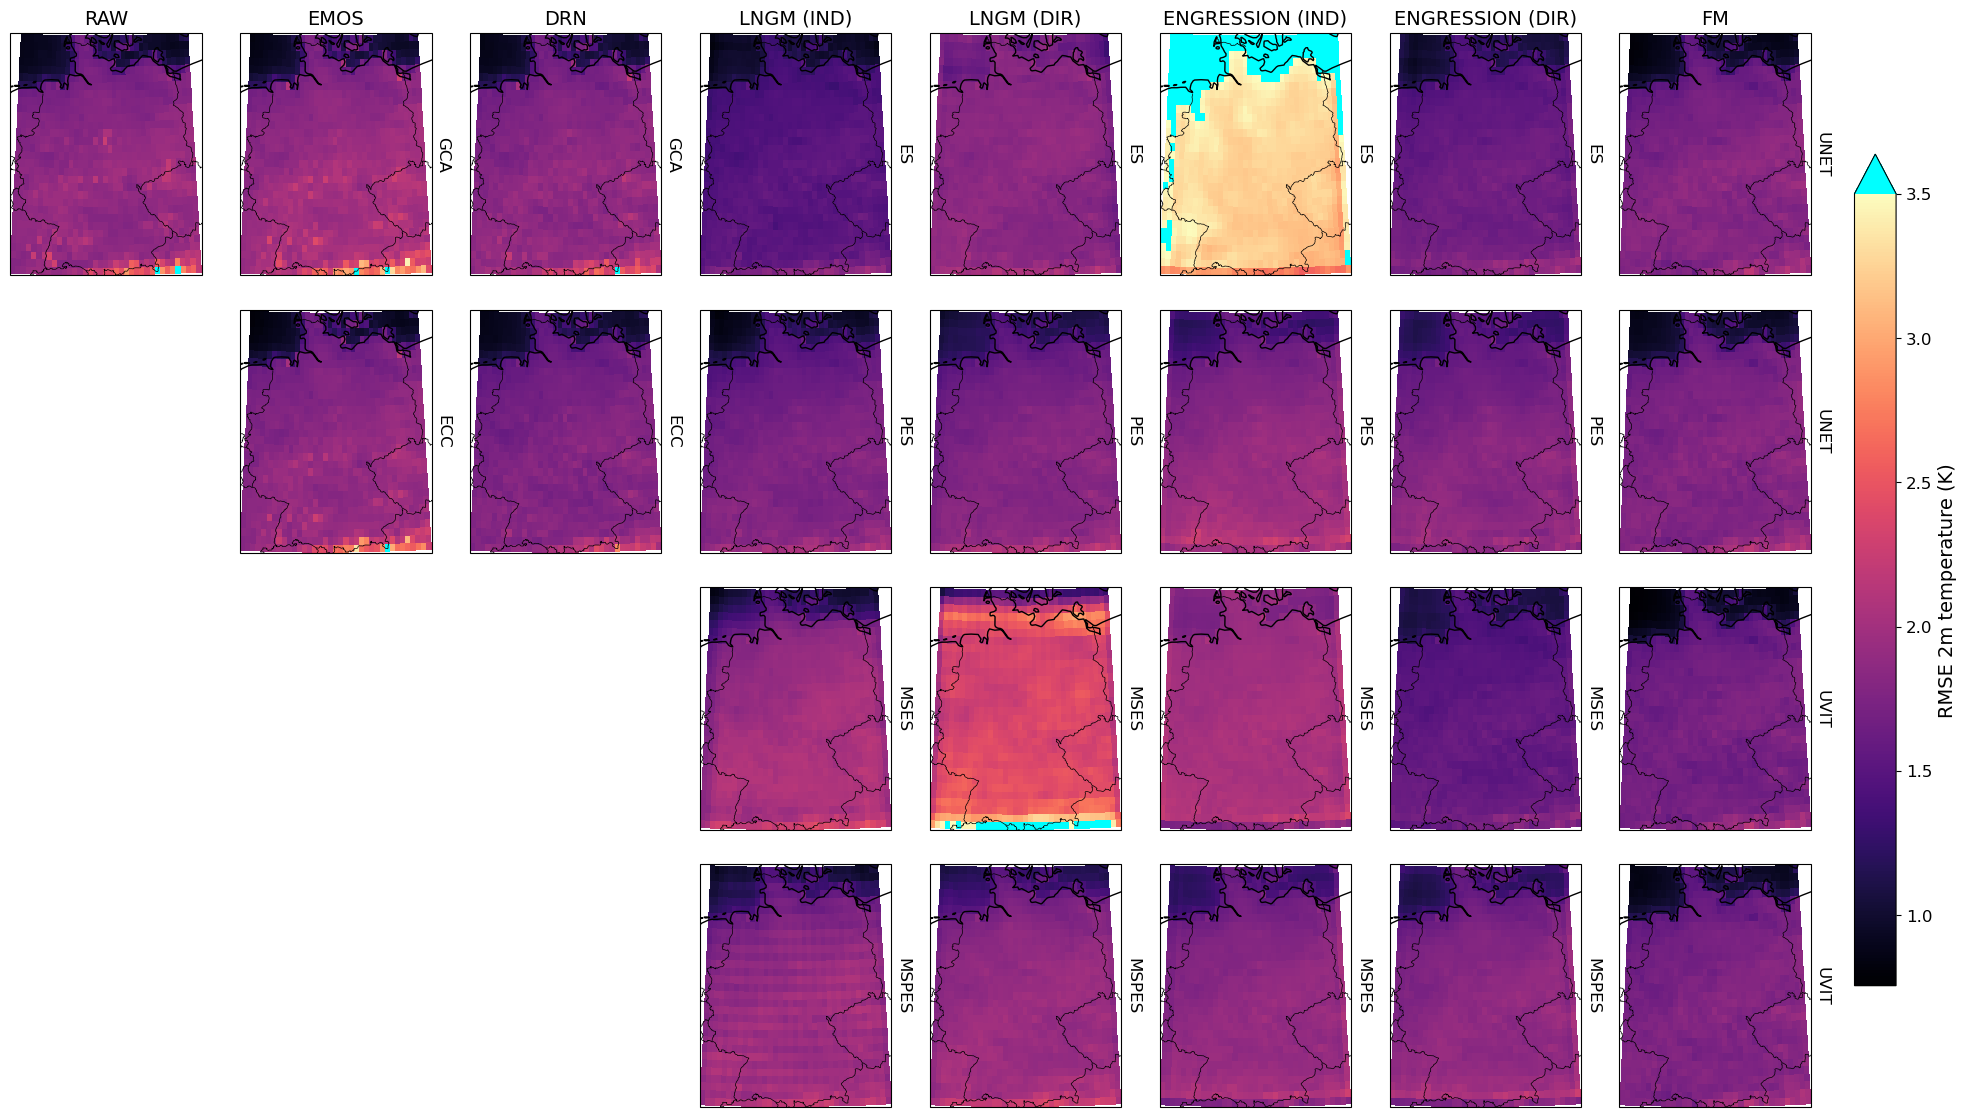

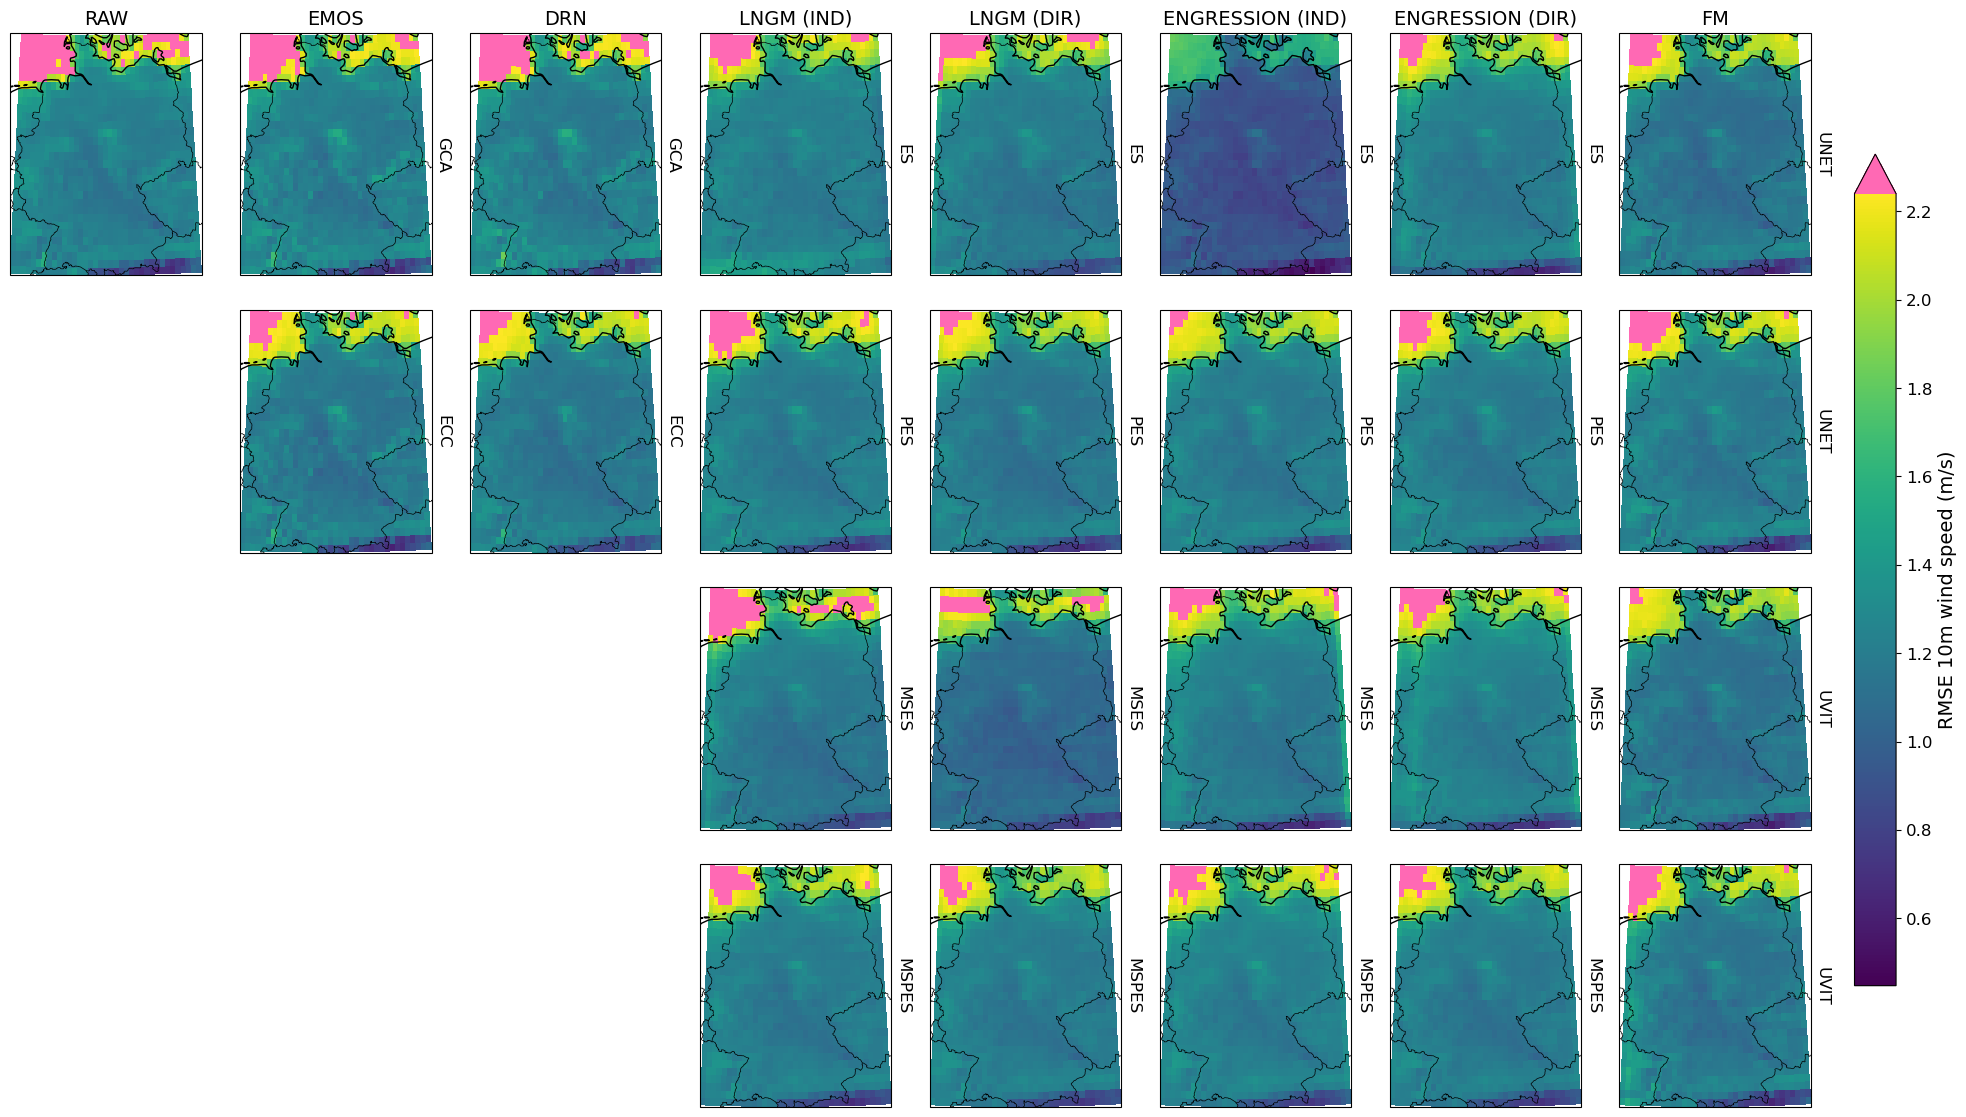

In [14]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

from genpp.plots import RESULTS_DIR

lon = combined.longitude
lat = combined.latitude

if SCORE == "rmse":
    VAR_DISPLAY_NAMES = {
        "2m_temperature": "2m temperature (K)",
        "10m_wind_speed": "10m wind speed (m/s)",
    }
elif SCORE == "crps":
    VAR_DISPLAY_NAMES = {
        "2m_temperature": "2m temperature",
        "10m_wind_speed": "10m wind speed",
    }

proj = ccrs.LambertConformal(central_longitude=10, central_latitude=51)

# Structured model layout matching notebook 03
# Each entry: (column_title, list of model names for that column's rows)
MODEL_COLUMNS = [
    ("RAW", ["raw"]),
    ("EMOS", ["emos_gca", "emos_ecc"]),
    ("DRN", ["drn_gca", "drn_ecc"]),
    ("LNGM (IND)", ["chen_ind_es", "chen_ind_pes", "chen_ind_mses", "chen_ind_mspes"]),
    ("LNGM (DIR)", ["chen_dir_es", "chen_dir_pes", "chen_dir_mses", "chen_dir_mspes"]),
    (
        "ENGRESSION (IND)",
        ["engression_ind_es", "engression_ind_pes", "engression_ind_mses", "engression_ind_mspes"],
    ),
    (
        "ENGRESSION (DIR)",
        ["engression_dir_es", "engression_dir_pes", "engression_dir_mses", "engression_dir_mspes"],
    ),
    ("FM", ["fm_ind_unet", "fm_dir_unet", "fm_ind_uvit", "fm_dir_uvit"]),
]

n_cols = len(MODEL_COLUMNS)
n_rows = max(len(models) for _, models in MODEL_COLUMNS)

for var in FC_VARS:
    cfg = var_settings[var]
    data = combined.sel(feature=var)  # (model, longitude, latitude)

    # Shared colour limits
    vmin = float(data.min())
    vmax = float(data.max())

    # Build colormap: cap vmax and mark over-values for temperature/wind
    cmap = plt.get_cmap(cfg["cmap"]).copy()
    if "vmax_cap" in cfg:
        vmax = cfg["vmax_cap"]
        cmap.set_over(cfg["over_color"])
    extend = "max" if "vmax_cap" in cfg else "neither"

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(3.5 * n_cols, 4.5 * n_rows),
        subplot_kw={"projection": proj},
    )
    fig.subplots_adjust(wspace=0.2, hspace=-0.5)
    axes = np.atleast_2d(axes)

    for col_idx, (col_title, model_list) in enumerate(MODEL_COLUMNS):
        for row_idx in range(n_rows):
            ax = axes[row_idx, col_idx]

            if row_idx < len(model_list):
                model_key = model_list[row_idx]
                da = data.sel(model=model_key)

                pcm = ax.pcolormesh(
                    lon,
                    lat,
                    da.T,
                    cmap=cmap,
                    vmin=vmin,
                    vmax=vmax,
                    transform=ccrs.PlateCarree(),
                    shading="auto",
                    rasterized=True,
                )
                ax.coastlines(resolution="50m")
                ax.add_feature(cfeature.BORDERS, linewidth=0.5)
                ax.set_xticks([])
                ax.set_yticks([])

                if row_idx == 0:
                    ax.set_title(col_title, fontsize=14)

                # Variant label on right side
                parts = model_key.split("_", 1)
                tag = parts[1] if len(parts) > 1 else ""
                # For chen/engression: strip ind_/dir_ prefix
                for prefix in ("ind_", "dir_"):
                    if tag.startswith(prefix):
                        tag = tag[len(prefix) :]
                        break
                if tag:
                    ax.text(
                        1.02,
                        0.5,
                        tag.upper(),
                        transform=ax.transAxes,
                        fontsize=12,
                        va="center",
                        ha="left",
                        rotation=-90,
                    )
            else:
                ax.set_visible(False)

    cbar = fig.colorbar(
        pcm,
        ax=axes.ravel().tolist(),
        orientation="vertical",
        label=cfg["label"],
        shrink=0.6,
        pad=0.02,
        extend=extend,
    )
    cbar.ax.tick_params(labelsize=12)
    cbar.set_label(cfg["label"], fontsize=14)

    # fig.suptitle(
    #     f"Mean Spatial {SCORE.upper()} - {VAR_DISPLAY_NAMES.get(var, var)}", fontsize=16, y=0.84
    # )

    out_dir = RESULTS_DIR / "results" / "wb2" / "spatial_errors"
    out_dir.mkdir(parents=True, exist_ok=True)
    plt.savefig(out_dir / f"spatial_{SCORE}_{var}.pdf", bbox_inches="tight")
    plt.show()

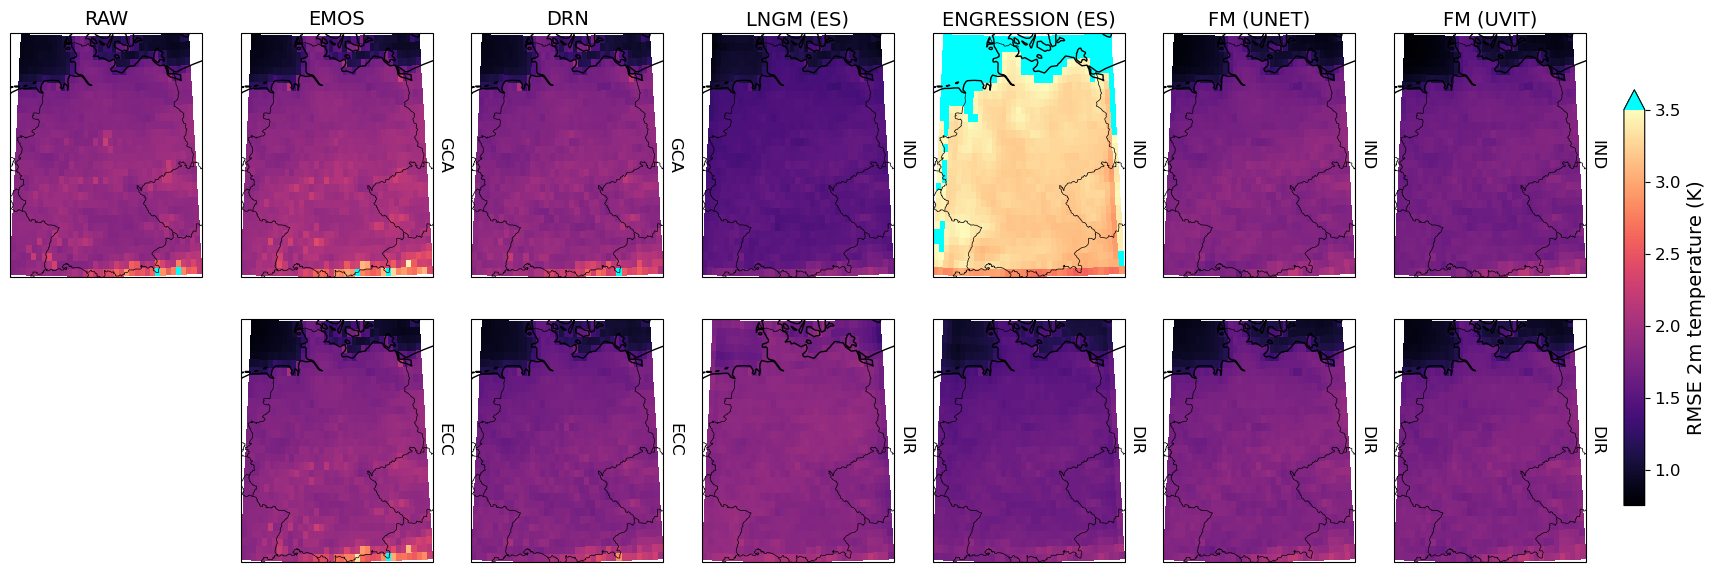

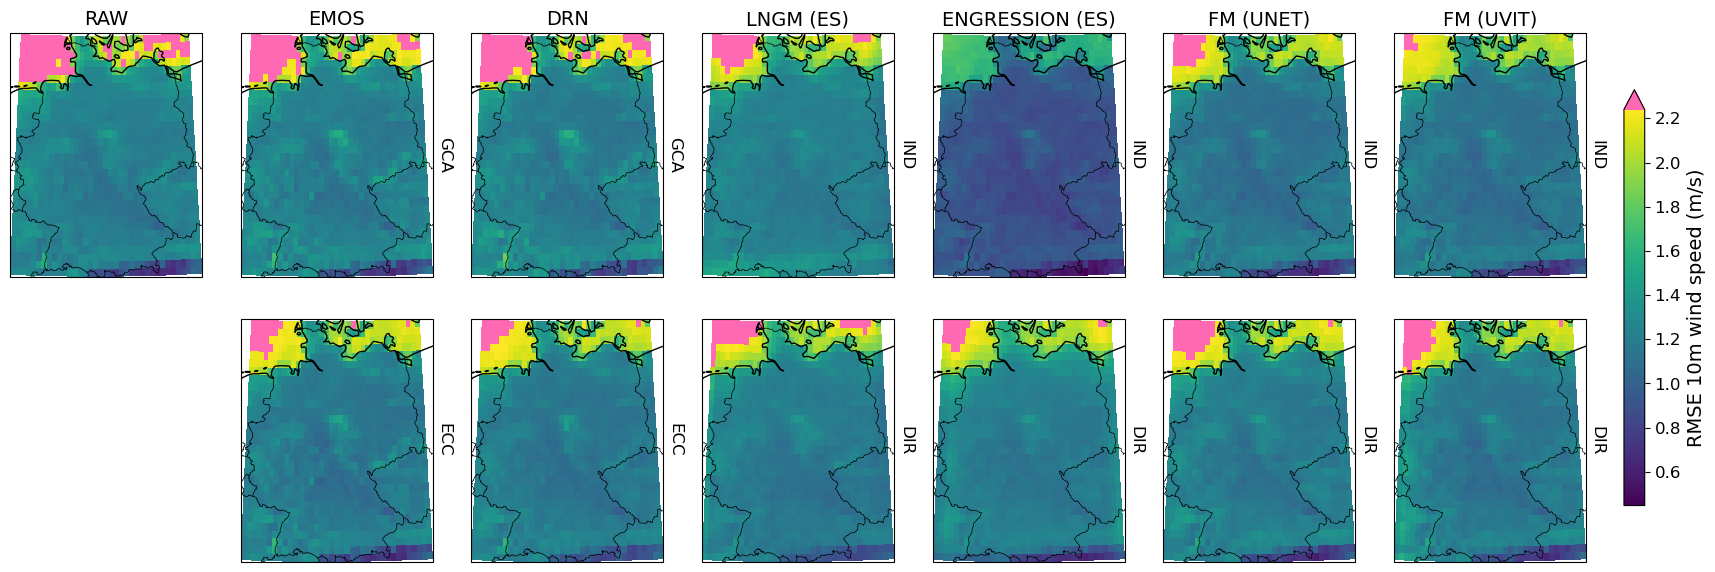

In [15]:
MODEL_COLUMNS_2 = [
    ("RAW", ["raw"], [""]),
    ("EMOS", ["emos_gca", "emos_ecc"], ["GCA", "ECC"]),
    ("DRN", ["drn_gca", "drn_ecc"], ["GCA", "ECC"]),
    ("LNGM (ES)", ["chen_ind_es", "chen_dir_es"], ["IND", "DIR"]),
    ("ENGRESSION (ES)", ["engression_ind_es", "engression_dir_es"], ["IND", "DIR"]),
    ("FM (UNET)", ["fm_ind_unet", "fm_dir_unet"], ["IND", "DIR"]),
    ("FM (UVIT)", ["fm_ind_uvit", "fm_dir_uvit"], ["IND", "DIR"]),
]

n_cols2 = len(MODEL_COLUMNS_2)
n_rows2 = max(len(models) for _, models, _ in MODEL_COLUMNS_2)

for var in FC_VARS:
    cfg = var_settings[var]
    data = combined.sel(feature=var)

    vmin = float(data.min())
    vmax = float(data.max())

    cmap = plt.get_cmap(cfg["cmap"]).copy()
    if "vmax_cap" in cfg:
        vmax = cfg["vmax_cap"]
        cmap.set_over(cfg["over_color"])
    extend = "max" if "vmax_cap" in cfg else "neither"

    fig, axes = plt.subplots(
        n_rows2,
        n_cols2,
        figsize=(3.5 * n_cols2, 4.5 * n_rows2),
        subplot_kw={"projection": proj},
    )
    fig.subplots_adjust(wspace=0.2, hspace=-0.3)
    axes = np.atleast_2d(axes)

    for col_idx, (col_title, model_list, row_labels) in enumerate(MODEL_COLUMNS_2):
        for row_idx in range(n_rows2):
            ax = axes[row_idx, col_idx]

            if row_idx < len(model_list):
                model_key = model_list[row_idx]
                da = data.sel(model=model_key)

                pcm = ax.pcolormesh(
                    lon,
                    lat,
                    da.T,
                    cmap=cmap,
                    vmin=vmin,
                    vmax=vmax,
                    transform=ccrs.PlateCarree(),
                    shading="auto",
                    rasterized=True,
                )
                ax.coastlines(resolution="50m")
                ax.add_feature(cfeature.BORDERS, linewidth=0.5)
                ax.set_xticks([])
                ax.set_yticks([])

                if row_idx == 0:
                    ax.set_title(col_title, fontsize=14)

                # Row label on right side
                label = row_labels[row_idx] if row_idx < len(row_labels) else ""
                if label:
                    ax.text(
                        1.02,
                        0.5,
                        label,
                        transform=ax.transAxes,
                        fontsize=12,
                        va="center",
                        ha="left",
                        rotation=-90,
                    )
            else:
                ax.set_visible(False)

    cbar = fig.colorbar(
        pcm,
        ax=axes.ravel().tolist(),
        orientation="vertical",
        label=cfg["label"],
        shrink=0.6,
        pad=0.02,
        extend=extend,
    )
    cbar.ax.tick_params(labelsize=12)
    cbar.set_label(cfg["label"], fontsize=14)

    # fig.suptitle(
    #     f"Mean Spatial {SCORE.upper()} - {VAR_DISPLAY_NAMES.get(var, var)}", fontsize=16, y=0.88
    # )

    out_dir = RESULTS_DIR / "results" / "wb2" / "spatial_errors"
    out_dir.mkdir(parents=True, exist_ok=True)
    plt.savefig(out_dir / f"spatial_{SCORE}_{var}_compact.pdf", bbox_inches="tight")
    plt.show()